# Regularization and Decision Trees

Two problems on UCI data. The first fits a classification tree to a clinical diagnosis set and reduces it, through cost-complexity pruning, to a handful of readable IF-THEN rules. The second is a 122-predictor regression on community crime rates, where ridge, LASSO, principal components and boosting are compared under one train and test split. Ridge takes the lowest test MSE at 0.01732; boosting drives training MSE down to 0.00670 without improving on it.

**Data:** Acute Inflammations, 120 instances with 6 features and 2 binary targets; and Communities and Crime, 1,994 instances with 122 predictors; UCI Machine Learning Repository
https://archive.ics.uci.edu/dataset/184/acute+inflammations
https://archive.ics.uci.edu/dataset/183/communities+and+crime

## Models
| Model | Section | What it does |
|---|---|---|
| Decision tree classifier | Decision tree | Multi-output tree on both binary targets; converted to IF-THEN rules |
| Cost-complexity pruned tree | Cost-complexity pruning | One tree per alpha on the pruning path; node count, impurity and accuracy tracked |
| KNN imputer | Missing value imputation | Five neighbors, filling missing values in the crime data |
| OLS | OLS and ridge | Least squares baseline on 122 predictors |
| Ridge regression | OLS and ridge | RidgeCV over 200 candidate penalties |
| LASSO, raw features | LASSO | LassoCV; penalty by 5-fold cross-validation |
| LASSO, standardized features | LASSO | Same fit after scaling; selected variables compared |
| Principal component regression | Principal component regression | PCA feeding linear regression; component count by 5-fold cross-validation |
| Gradient boosting | Gradient boosting | XGBRegressor with 250 trees; L1 penalty tuned by 5-fold cross-validation |

## Contents
| Section | What it covers |
|---|---|
| Decision tree | Multi-output classification tree on the acute inflammations data |
| Rule extraction | Tree converted to nested IF-THEN rules over the six symptoms |
| Cost-complexity pruning | Node count, impurity and training accuracy across the pruning path |
| Missing value imputation | Five-neighbor KNN imputation on the crime data |
| Feature screening | Correlation matrix and coefficient of variation ranking, with plots for the top 11 features |
| OLS and ridge | Least squares baseline, then RidgeCV over 200 candidate penalties |
| LASSO | LassoCV on raw and on standardized features, with the two selected coefficient sets |
| Principal component regression | Component count chosen by 5-fold cross-validation |
| Gradient boosting | XGBoost with an L1 penalty tuned by cross-validation |

## 1. Decision Trees as Interpretable Models


Import packages

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import tree

from sklearn.impute import KNNImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import KFold, cross_val_score
from sklearn.decomposition import PCA

import xgboost as xgb


### (a) Obtain Acute Inflammations Data
- Data Source: https://archive.ics.uci.edu/dataset/184/acute+inflammations
| Variable Name        | Code | Role             | Value  |
|----------------------|------|------------------|---------|
| temperature          | a1   | Feature          | float   |
| nausea               | a2   | Feature          | binary  |
| lumbar-pain          | a3   | Feature          | binary  |
| urine-pushing        | a4   | Feature          | binary  |
| micturition-pains    | a5   | Feature          | binary  |
| burning-urethra      | a6   | Feature          | binary  |
| bladder-inflammation | d1   | Target (Label 1) | binary  |
| nephritis            | d2   | Target (Label 2) | binary  |

In [19]:
df = pd.read_csv('data/diagnosis.data',  sep='\t', header=None, names= ['temperature', 'nausea', 'lumbar-pain', 'urine-pushing', 'micturition-pains', 'burning-urethra', 'bladder-inflammation', 'nephritis'], encoding='utf-16')
print(df.shape)
print(df.dtypes)
display(df)


(120, 8)
temperature             str
nausea                  str
lumbar-pain             str
urine-pushing           str
micturition-pains       str
burning-urethra         str
bladder-inflammation    str
nephritis               str
dtype: object


,temperature,nausea,lumbar-pain,urine-pushing,micturition-pains,burning-urethra,bladder-inflammation,nephritis
0,"35,5",no,yes,no,no,no,no,no
1,"35,9",no,no,yes,yes,yes,yes,no
2,"35,9",no,yes,no,no,no,no,no
3,"36,0",no,no,yes,yes,yes,yes,no
4,"36,0",no,yes,no,no,no,no,no
...,...,...,...,...,...,...,...,...
115,"41,4",no,yes,yes,no,yes,no,yes
116,"41,5",no,no,no,no,no,no,no
117,"41,5",yes,yes,no,yes,no,no,yes
118,"41,5",no,yes,yes,no,yes,no,yes


In [20]:
df = df.replace({'yes': 1, 'no': 0})
df['temperature'] = df['temperature'].str.replace(',', '.').astype(float)
cols = df.columns.drop('temperature')
df[cols] = df[cols].astype(int)
print(df.shape)
print(df.dtypes)
display(df)

(120, 8)
temperature             float64
nausea                    int64
lumbar-pain               int64
urine-pushing             int64
micturition-pains         int64
burning-urethra           int64
bladder-inflammation      int64
nephritis                 int64
dtype: object


,temperature,nausea,lumbar-pain,urine-pushing,micturition-pains,burning-urethra,bladder-inflammation,nephritis
0,35.5,0,1,0,0,0,0,0
1,35.9,0,0,1,1,1,1,0
2,35.9,0,1,0,0,0,0,0
3,36.0,0,0,1,1,1,1,0
4,36.0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...
115,41.4,0,1,1,0,1,0,1
116,41.5,0,0,0,0,0,0,0
117,41.5,1,1,0,1,0,0,1
118,41.5,0,1,1,0,1,0,1


### (b) Build a decision tree

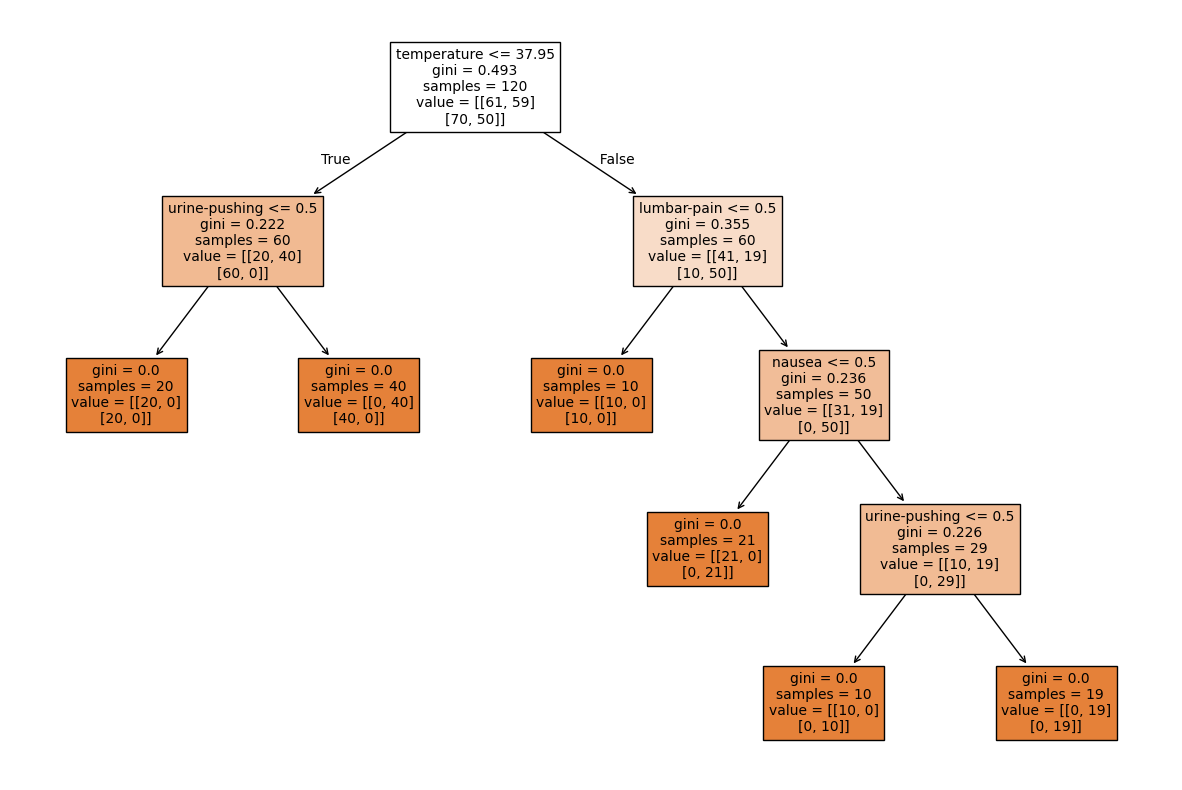

In [21]:
y = df[['bladder-inflammation', 'nephritis']]
X = df.drop(columns=y)

dt_full = tree.DecisionTreeClassifier(criterion='gini', random_state=42)
dt_full.fit(X, y)

plt.figure(figsize=(15, 10))
tree.plot_tree(dt_full, feature_names=X.columns, filled=True,fontsize=10)
plt.show()


### (c) Convert the decision rules
Used method from https://www.kdnuggets.com/2017/05/simplifying-decision-tree-interpretation-decision-rules-python.html

In [22]:
def tree_to_pseudo(tree, feature_names, class_names):
    left = tree.tree_.children_left
    right = tree.tree_.children_right
    threshold = tree.tree_.threshold
    features = [feature_names[i] for i in tree.tree_.feature]
    value = tree.tree_.value

    def recurse(left, right, threshold, features, node, depth=0):
        indent = "  " * depth
        if threshold[node] != -2:
            print(indent, "If (" + features[node] + " <= " + str(threshold[node]) + ")")
            if left[node] != -1:
                recurse(left, right, threshold, features, left[node], depth + 1)
            print(indent, "If (" + features[node] + " > " + str(threshold[node]) + ")")
            if right[node] != -1:
                recurse(left, right, threshold, features, right[node], depth + 1)
        else:
            prediction = {class_names[i]: int(value[node][i].argmax())
                          for i in range(len(class_names))}
            print(indent, "Then " + str(prediction))

    recurse(left, right, threshold, features, 0)

tree_to_pseudo(dt_full, X.columns.tolist(), y.columns.tolist())

 If (temperature <= 37.95000076293945)
   If (urine-pushing <= 0.5)
     Then {'bladder-inflammation': 0, 'nephritis': 0}
   If (urine-pushing > 0.5)
     Then {'bladder-inflammation': 1, 'nephritis': 0}
 If (temperature > 37.95000076293945)
   If (lumbar-pain <= 0.5)
     Then {'bladder-inflammation': 0, 'nephritis': 0}
   If (lumbar-pain > 0.5)
     If (nausea <= 0.5)
       Then {'bladder-inflammation': 0, 'nephritis': 1}
     If (nausea > 0.5)
       If (urine-pushing <= 0.5)
         Then {'bladder-inflammation': 0, 'nephritis': 1}
       If (urine-pushing > 0.5)
         Then {'bladder-inflammation': 1, 'nephritis': 1}


### (d) Use cost-complexity pruning and a set of decision rules with high interpretability.

,Alpha,Impurity,Node_Count,Depth,Train Accuracy
0,0.000000,0.000000,11,4,1.000000
1,0.049083,0.098167,7,2,0.841667
2,0.079472,0.177639,5,2,0.758333
3,0.111111,0.288750,3,1,0.591667
4,0.204236,0.492986,1,0,0.250000


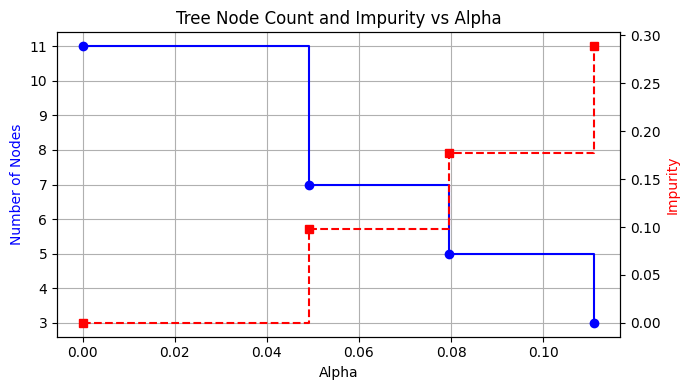

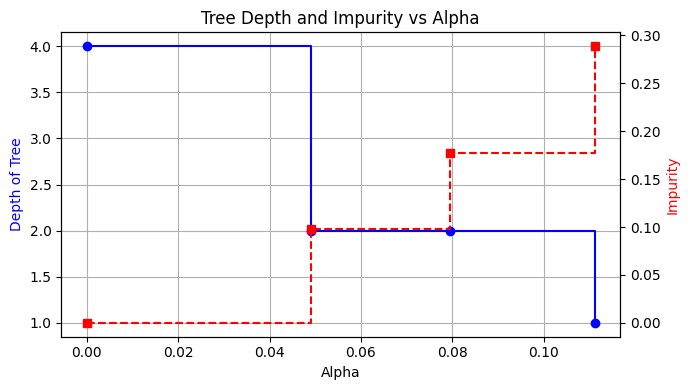

In [23]:
path = dt_full.cost_complexity_pruning_path(X, y)
alphas  = path.ccp_alphas
impurities = path.impurities

trees = []
for alpha in alphas:
    dt_pruned = tree.DecisionTreeClassifier(criterion='gini',ccp_alpha = alpha, random_state=42)
    dt_pruned.fit(X, y)
    trees.append(dt_pruned)

metr_df = pd.DataFrame({
    'Alpha': alphas,
    'Impurity': impurities,
    'Node_Count': [t.tree_.node_count for t in trees],
    'Depth': [t.tree_.max_depth for t in trees],
    'Train Accuracy': [t.score(X, y) for t in trees]
})
display(metr_df)

plot_df = metr_df.iloc[:-1]
fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.plot(plot_df['Alpha'], plot_df['Node_Count'], marker="o", drawstyle="steps-post", color='blue')
ax1.set_xlabel('Alpha')
ax1.set_ylabel('Number of Nodes', color='blue')
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(plot_df['Alpha'], plot_df['Impurity'], marker="s", drawstyle="steps-post", color='red', linestyle='--')
ax2.set_ylabel('Impurity', color='red')

plt.title("Tree Node Count and Impurity vs Alpha")
fig.tight_layout()
plt.show()

fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.plot(plot_df['Alpha'], plot_df['Depth'], marker="o", drawstyle="steps-post", color='blue')
ax1.set_xlabel('Alpha')
ax1.set_ylabel('Depth of Tree', color='blue')
ax1.grid(True)
ax2 = ax1.twinx()
ax2.plot(plot_df['Alpha'], plot_df['Impurity'], marker="s", drawstyle="steps-post", color='red', linestyle='--')
ax2.set_ylabel('Impurity', color='red')

plt.title("Tree Depth and Impurity vs Alpha")
fig.tight_layout()
plt.show()

Full tree ($\alpha = 0.0$) achieves perfect scores; it is much more complex and likely overfits the data. Hence, for this problem, to find a minimal decision tree and a set of decision rules with high interpretability, we selected the pruned tree with $\alpha = 0.049$. It cuts the node count almost in half (down to 7 nodes), hence significantly increasing interpretability, while maintaining low impurity and a reasonably high training accuracy of 0.8417.

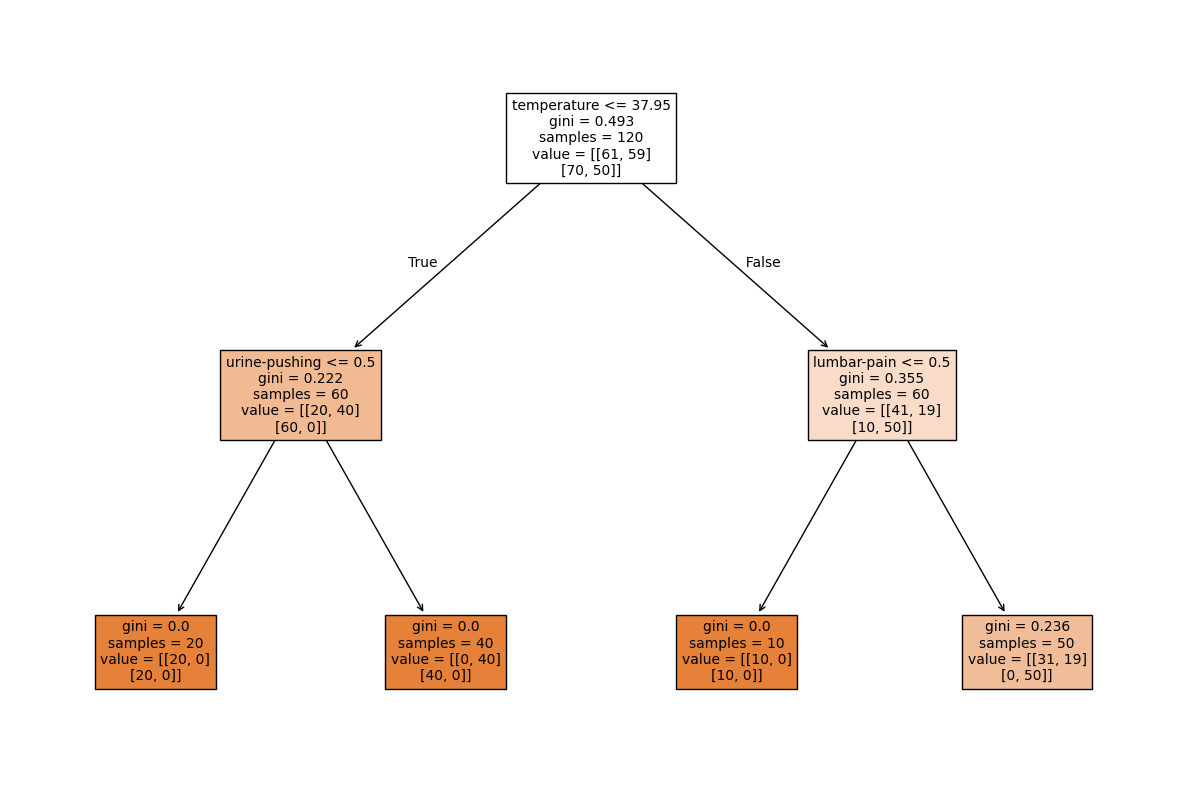

 If (temperature <= 37.95000076293945)
   If (urine-pushing <= 0.5)
     Then {'bladder-inflammation': 0, 'nephritis': 0}
   If (urine-pushing > 0.5)
     Then {'bladder-inflammation': 1, 'nephritis': 0}
 If (temperature > 37.95000076293945)
   If (lumbar-pain <= 0.5)
     Then {'bladder-inflammation': 0, 'nephritis': 0}
   If (lumbar-pain > 0.5)
     Then {'bladder-inflammation': 0, 'nephritis': 1}


In [24]:
min_tree = trees[1]
plt.figure(figsize=(15, 10))
tree.plot_tree(min_tree, feature_names=X.columns, filled=True,fontsize=10)
plt.show()
tree_to_pseudo(min_tree, X.columns.tolist(), y.columns.tolist())

## 2. The LASSO and Boosting for Regression

### (a) Obtain Crime Data
- Data Source: https://archive.ics.uci.edu/dataset/183/communities+and+crime
- All fetures are normalized to [0, 1]
- Attribute Information: (122 predictive, 5 non-predictive, 1 target)
- **Target Varibale:** `ViolentCrimesPerPop` — per capita violent crimes (continuous)

In [25]:
with open('data/communities.names', 'r') as f:
    lines = f.readlines()
col_names = [line.split()[1] for line in lines if line.startswith('@attribute')]

df = pd.read_csv('data/communities.data', sep=',', header=None, names=col_names, na_values='?')
print("Full data shape: ", df.shape)
display(df)

non_predict = ['state', 'county', 'community', 'communityname', 'fold']
df = df.drop(columns=non_predict)

X = df.drop(columns=['ViolentCrimesPerPop'])
y = df['ViolentCrimesPerPop']

X_train, X_test = X.iloc[:1495], X.iloc[1495:]
y_train, y_test = y.iloc[:1495], y.iloc[1495:]

print("X and y train data shape:", X_train.shape, y_train.shape)
print("X and y test data shape:", X_test.shape, y_test.shape)

Full data shape:  (1994, 128)


,state,county,community,communityname,fold,population,householdsize,racepctblack,racePctWhite,racePctAsian,...,LandArea,PopDens,PctUsePubTrans,PolicCars,PolicOperBudg,LemasPctPolicOnPatr,LemasGangUnitDeploy,LemasPctOfficDrugUn,PolicBudgPerPop,ViolentCrimesPerPop
0,8,NaN,NaN,Lakewoodcity,1,0.19,0.33,0.02,0.90,0.12,...,0.12,0.26,0.20,0.06,0.04,0.90,0.5,0.32,0.14,0.20
1,53,NaN,NaN,Tukwilacity,1,0.00,0.16,0.12,0.74,0.45,...,0.02,0.12,0.45,NaN,NaN,NaN,NaN,0.00,NaN,0.67
2,24,NaN,NaN,Aberdeentown,1,0.00,0.42,0.49,0.56,0.17,...,0.01,0.21,0.02,NaN,NaN,NaN,NaN,0.00,NaN,0.43
3,34,5.0,81440.0,Willingborotownship,1,0.04,0.77,1.00,0.08,0.12,...,0.02,0.39,0.28,NaN,NaN,NaN,NaN,0.00,NaN,0.12
4,42,95.0,6096.0,Bethlehemtownship,1,0.01,0.55,0.02,0.95,0.09,...,0.04,0.09,0.02,NaN,NaN,NaN,NaN,0.00,NaN,0.03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1989,12,NaN,NaN,TempleTerracecity,10,0.01,0.40,0.10,0.87,0.12,...,0.01,0.28,0.05,NaN,NaN,NaN,NaN,0.00,NaN,0.09
1990,6,NaN,NaN,Seasidecity,10,0.05,0.96,0.46,0.28,0.83,...,0.02,0.37,0.20,NaN,NaN,NaN,NaN,0.00,NaN,0.45
1991,9,9.0,80070.0,Waterburytown,10,0.16,0.37,0.25,0.69,0.04,...,0.08,0.32,0.18,0.08,0.06,0.78,0.0,0.91,0.28,0.23
1992,25,17.0,72600.0,Walthamcity,10,0.08,0.51,0.06,0.87,0.22,...,0.03,0.38,0.33,0.02,0.02,0.79,0.0,0.22,0.18,0.19


X and y train data shape: (1495, 122) (1495,)
X and y test data shape: (499, 122) (499,)


### (b) Handle missing values with KNN Imputation.

In [26]:
impute = KNNImputer(n_neighbors=5)
X_train = pd.DataFrame(impute.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test  = pd.DataFrame(impute.transform(X_test),      columns=X_train.columns, index=X_test.index)
display(X_train)
display(X_test)


,population,householdsize,racepctblack,racePctWhite,racePctAsian,racePctHisp,agePct12t21,agePct12t29,agePct16t24,agePct65up,...,PolicAveOTWorked,LandArea,PopDens,PctUsePubTrans,PolicCars,PolicOperBudg,LemasPctPolicOnPatr,LemasGangUnitDeploy,LemasPctOfficDrugUn,PolicBudgPerPop
0,0.19,0.33,0.02,0.90,0.12,0.17,0.34,0.47,0.29,0.32,...,0.290,0.12,0.26,0.20,0.060,0.040,0.900,0.5,0.32,0.140
1,0.00,0.16,0.12,0.74,0.45,0.07,0.26,0.59,0.35,0.27,...,0.326,0.02,0.12,0.45,0.098,0.038,0.806,0.4,0.00,0.220
2,0.00,0.42,0.49,0.56,0.17,0.04,0.39,0.47,0.28,0.32,...,0.164,0.01,0.21,0.02,0.152,0.040,0.748,0.8,0.00,0.296
3,0.04,0.77,1.00,0.08,0.12,0.10,0.51,0.50,0.34,0.21,...,0.202,0.02,0.39,0.28,0.054,0.022,0.846,0.3,0.00,0.142
4,0.01,0.55,0.02,0.95,0.09,0.05,0.38,0.38,0.23,0.36,...,0.390,0.04,0.09,0.02,0.044,0.020,0.708,0.0,0.00,0.332
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1490,0.00,0.59,0.01,0.69,1.00,0.07,0.41,0.28,0.23,0.57,...,0.324,0.02,0.14,0.22,0.030,0.016,0.764,0.2,0.00,0.192
1491,0.16,0.62,0.03,0.74,0.48,0.42,0.44,0.57,0.40,0.25,...,0.380,0.07,0.40,0.14,0.070,0.050,0.850,0.5,0.61,0.190
1492,0.01,0.36,0.95,0.24,0.03,0.01,0.44,0.42,0.27,0.63,...,0.200,0.03,0.12,0.01,0.152,0.040,0.794,0.8,0.00,0.306
1493,0.06,0.53,0.01,0.98,0.05,0.01,0.40,0.40,0.24,0.29,...,0.350,0.08,0.15,0.02,0.052,0.022,0.718,0.2,0.00,0.324


,population,householdsize,racepctblack,racePctWhite,racePctAsian,racePctHisp,agePct12t21,agePct12t29,agePct16t24,agePct65up,...,PolicAveOTWorked,LandArea,PopDens,PctUsePubTrans,PolicCars,PolicOperBudg,LemasPctPolicOnPatr,LemasGangUnitDeploy,LemasPctOfficDrugUn,PolicBudgPerPop
1495,0.00,0.20,0.03,0.91,0.23,0.05,0.15,0.19,0.09,0.42,...,0.646,0.01,0.23,0.73,0.018,0.020,0.814,0.6,0.00,0.216
1496,0.00,0.55,0.13,0.78,0.15,0.36,0.48,0.53,0.30,0.10,...,0.260,0.01,0.18,0.02,0.100,0.028,0.688,0.5,0.00,0.284
1497,0.00,0.52,0.04,0.59,0.05,0.62,0.84,0.78,0.75,0.43,...,0.278,0.01,0.18,0.00,0.068,0.020,0.686,0.7,0.00,0.128
1498,0.04,0.51,0.07,0.92,0.09,0.03,0.38,0.47,0.27,0.35,...,0.312,0.06,0.13,0.16,0.034,0.018,0.820,0.0,0.00,0.152
1499,0.03,0.59,0.20,0.75,0.19,0.10,0.38,0.62,0.35,0.11,...,0.174,0.03,0.23,0.06,0.076,0.030,0.802,0.4,0.00,0.152
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1989,0.01,0.40,0.10,0.87,0.12,0.16,0.43,0.51,0.35,0.30,...,0.186,0.01,0.28,0.05,0.072,0.030,0.822,0.5,0.00,0.156
1990,0.05,0.96,0.46,0.28,0.83,0.32,0.69,0.86,0.73,0.14,...,0.612,0.02,0.37,0.20,0.140,0.092,0.670,0.6,0.00,0.238
1991,0.16,0.37,0.25,0.69,0.04,0.25,0.35,0.50,0.31,0.54,...,0.250,0.08,0.32,0.18,0.080,0.060,0.780,0.0,0.91,0.280
1992,0.08,0.51,0.06,0.87,0.22,0.10,0.58,0.74,0.63,0.41,...,0.190,0.03,0.38,0.33,0.020,0.020,0.790,0.0,0.22,0.180


### (c) Plot a correlation matrix

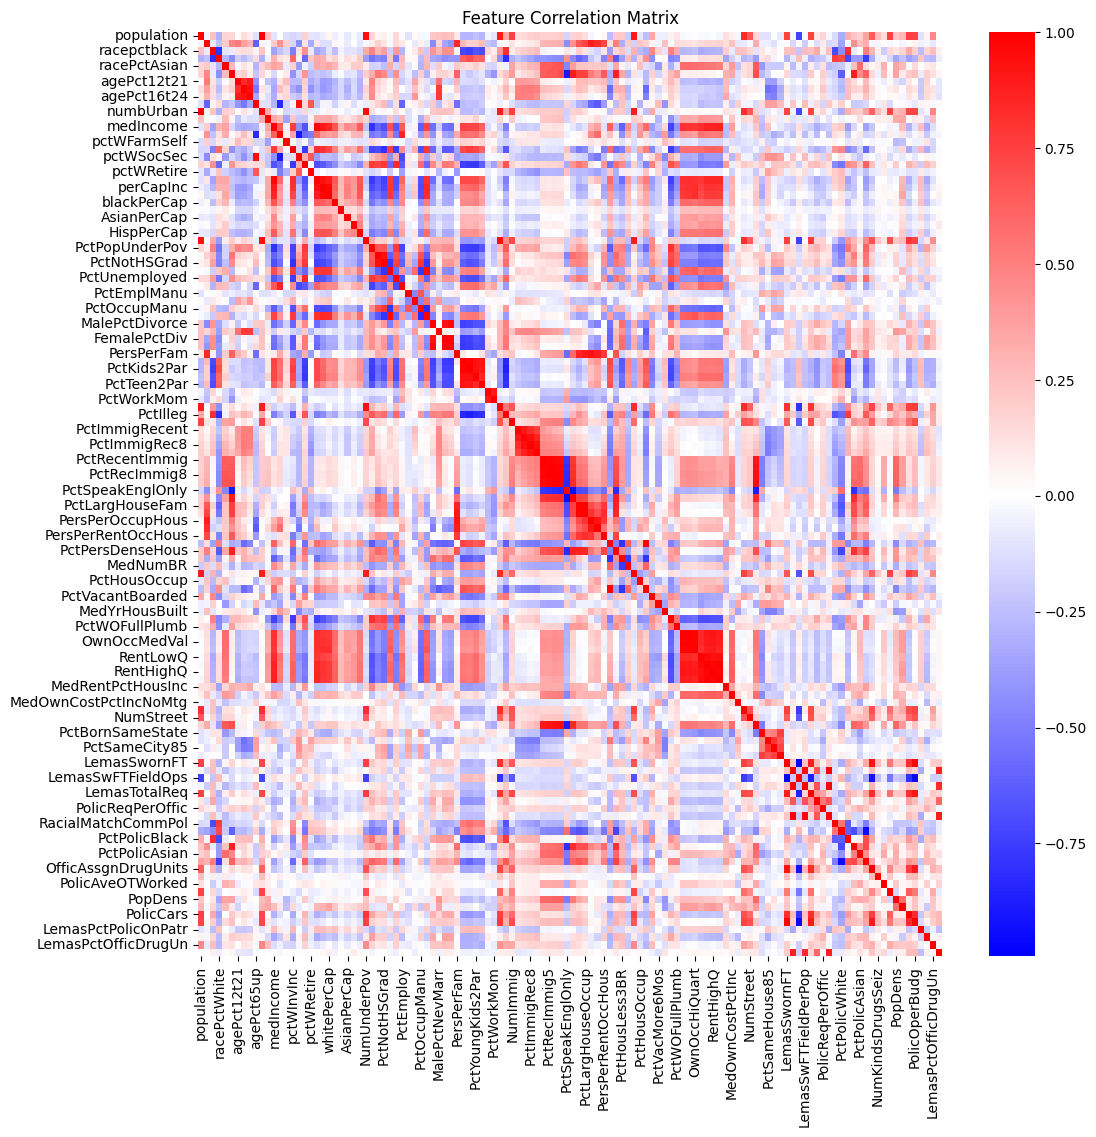

In [27]:
corr_m = X_train.corr()
plt.figure(figsize=(12, 12))
sns.heatmap(corr_m, cmap='bwr', center=0)
plt.title('Feature Correlation Matrix')
plt.show()

### (d) Calculate the Coefficient of Variation $CV$ for each feature, where $CV = \frac{s}{m}$
($ s =$  sample standard deviation; $ m =$ is sample mean)

,Mean,Std,CV
NumStreet,0.022983,0.098665,4.292923
NumInShelters,0.029599,0.102736,3.470952
NumIlleg,0.037204,0.113806,3.058964
NumImmig,0.030595,0.089541,2.926635
LemasPctOfficDrugUn,0.093304,0.238201,2.552946
...,...,...,...
RacialMatchCommPol,0.760499,0.158008,0.207769
NumKindsDrugsSeiz,0.534086,0.100591,0.188343
PctPolicWhite,0.821719,0.153686,0.187029
LemasPctPolicOnPatr,0.736401,0.116032,0.157567


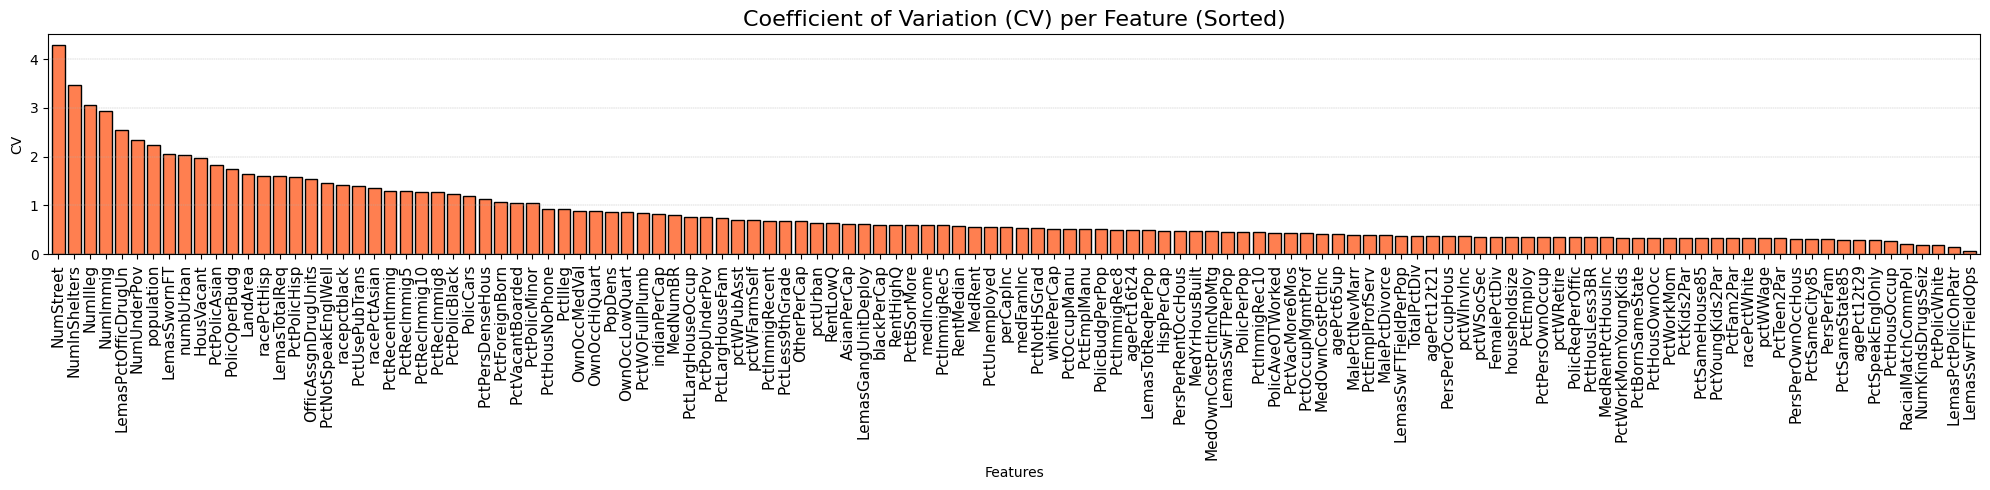

In [28]:
std_f = X_train.std()
mean_f = X_train.mean()
cv_f = std_f / mean_f

cv_df = pd.DataFrame({'Mean': mean_f, 'Std': std_f, 'CV': cv_f})
cv_df_sort = cv_df.sort_values(by='CV', ascending=False)
display(cv_df_sort)

plt.figure(figsize=(20, 5))
cv_df_sort['CV'].plot(kind='bar', color='coral', edgecolor='black', width=0.8)
plt.title('Coefficient of Variation (CV) per Feature (Sorted)', fontsize=16)
plt.xlabel('Features')
plt.ylabel('CV')
plt.xticks(fontsize=11)
plt.grid(axis='y', linestyle='--', linewidth=0.3)
plt.tight_layout()
plt.show()

### (e) Pick $\lfloor\sqrt{128}\rfloor$ features with highest CV, and make scatter plots and box plots for them.

Highest 11 CV features: ['NumStreet', 'NumInShelters', 'NumIlleg', 'NumImmig', 'LemasPctOfficDrugUn', 'NumUnderPov', 'population', 'LemasSwornFT', 'numbUrban', 'HousVacant', 'PctPolicAsian'] 



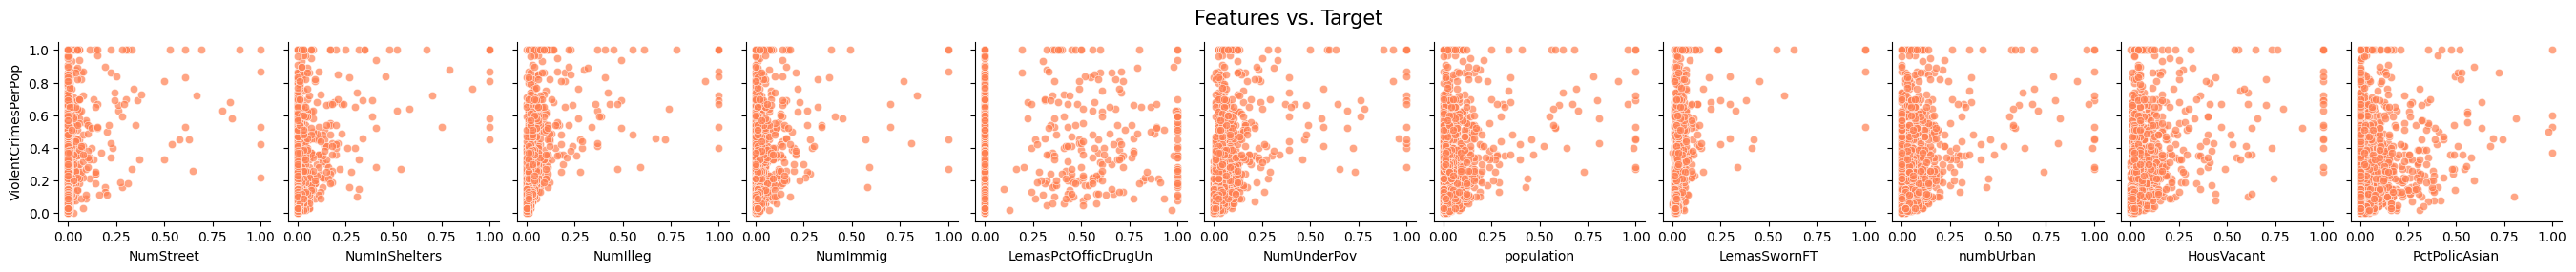

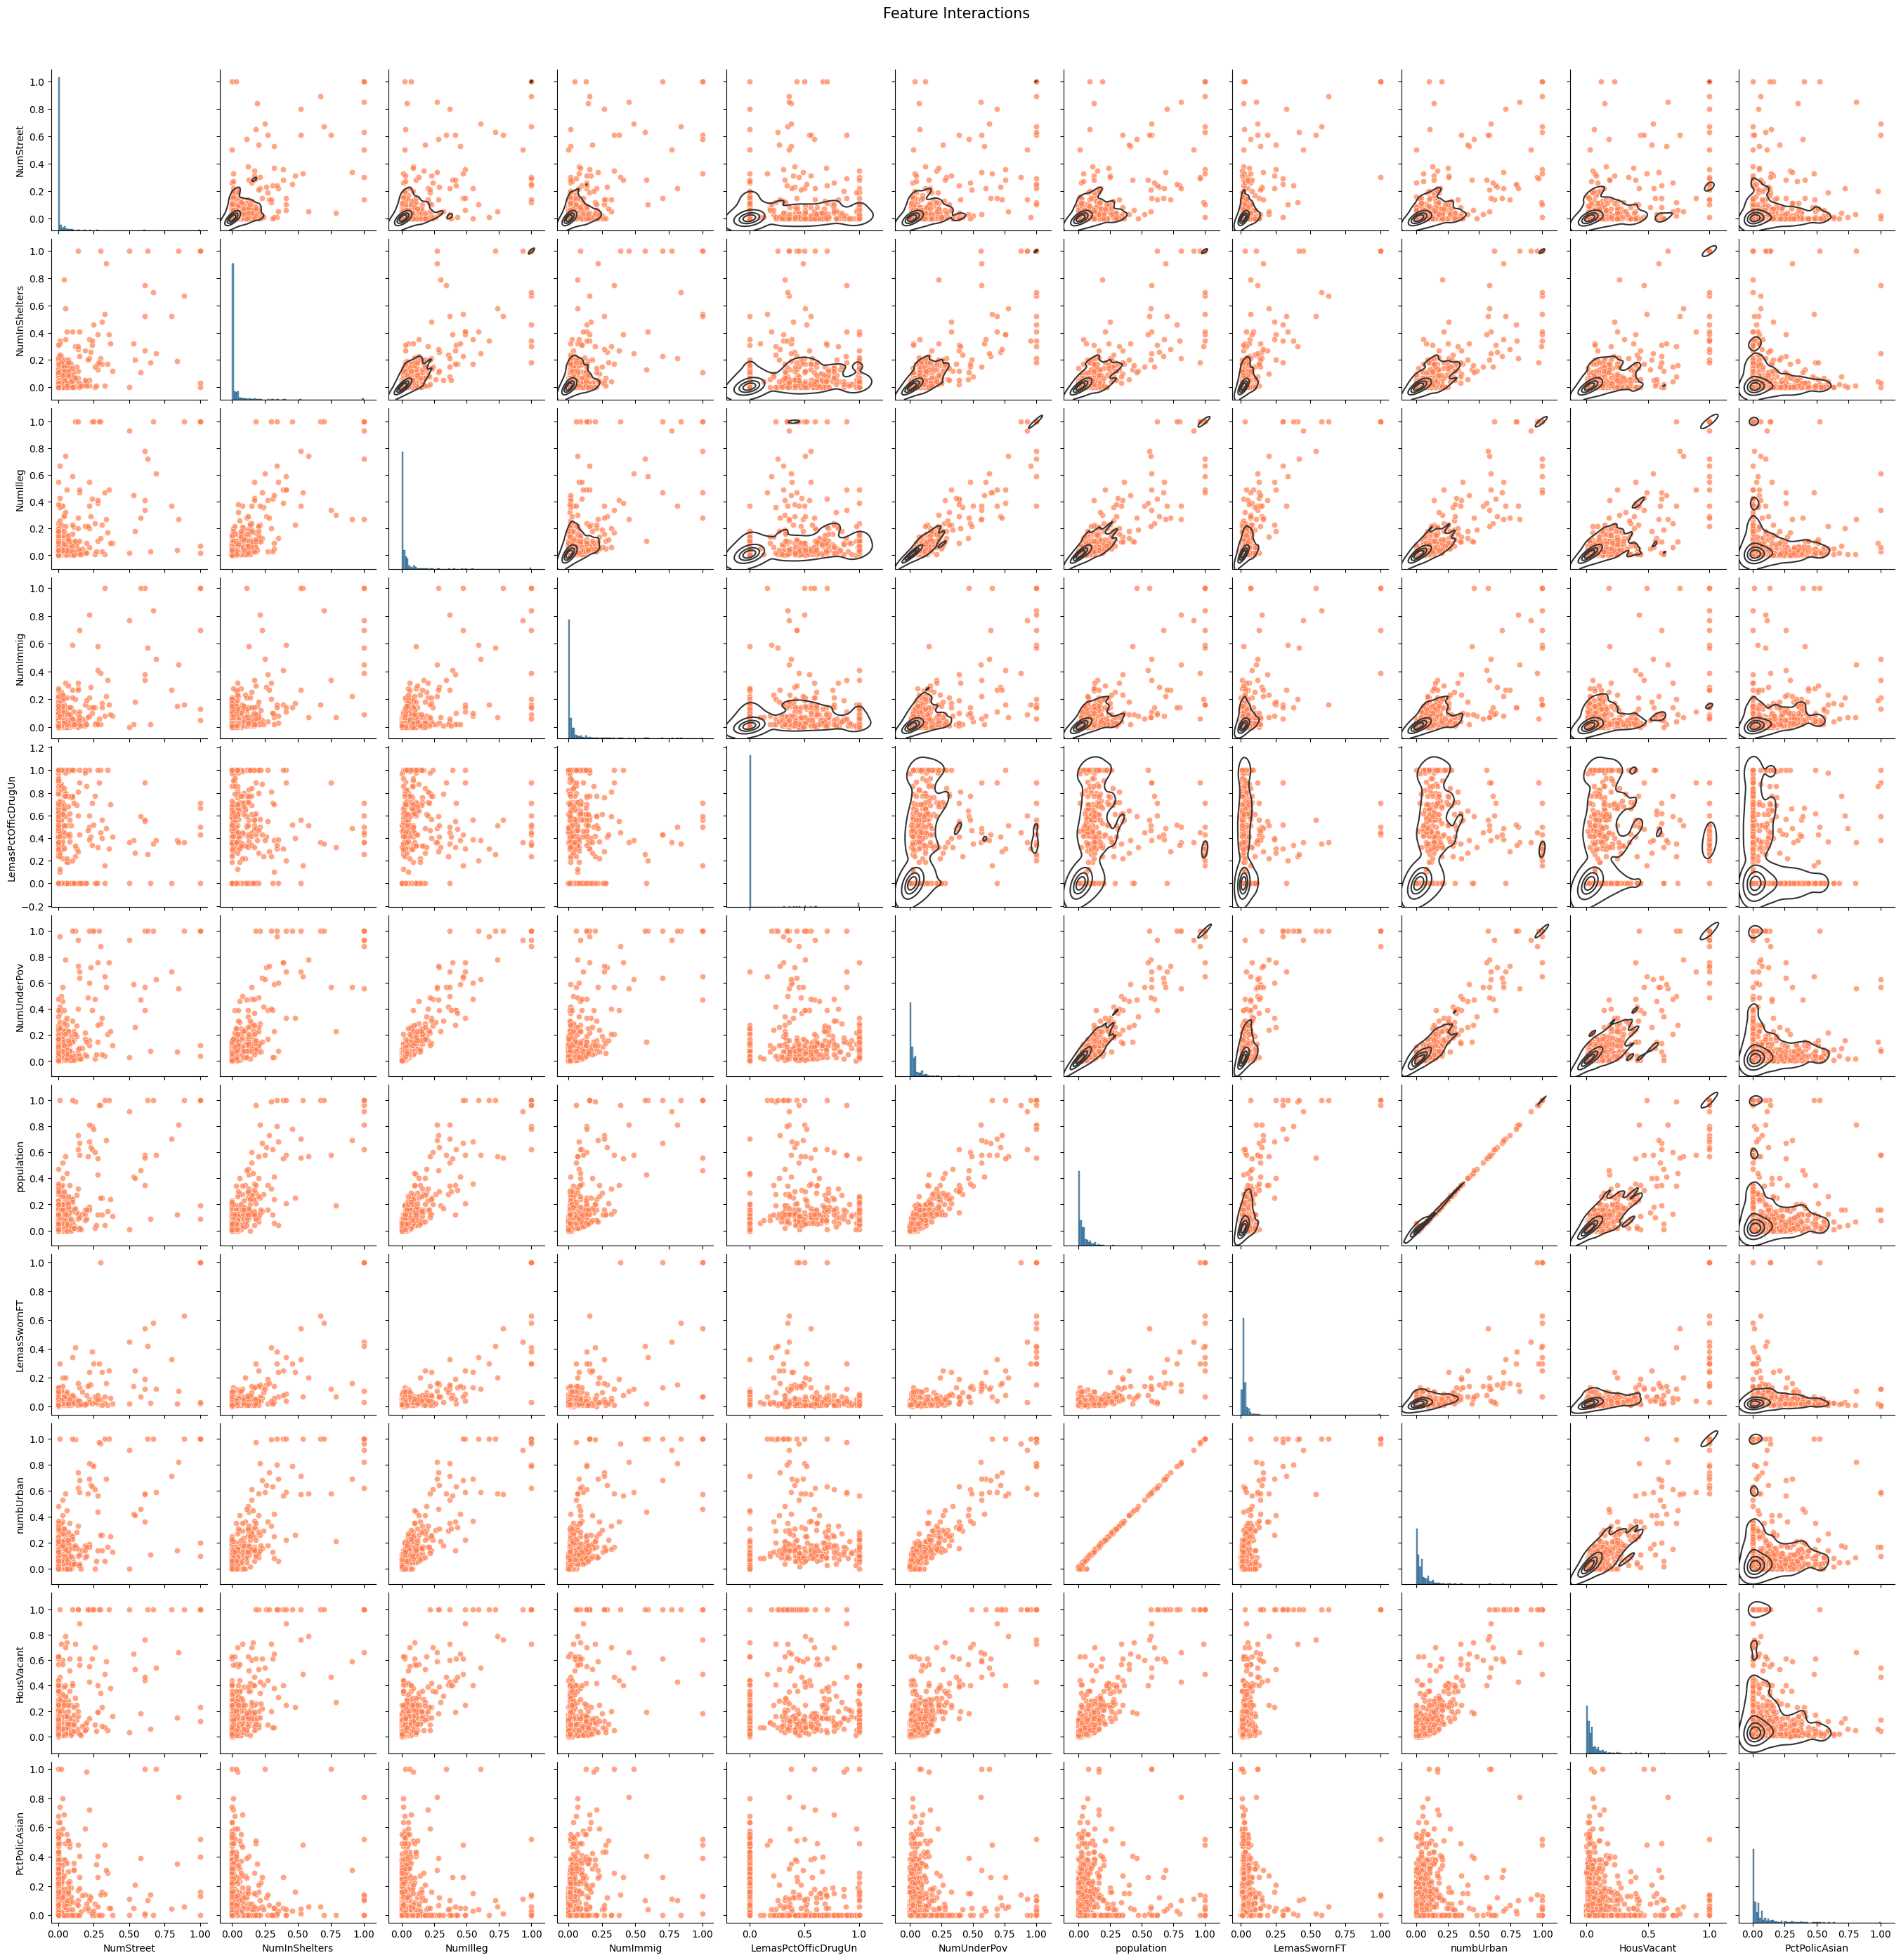

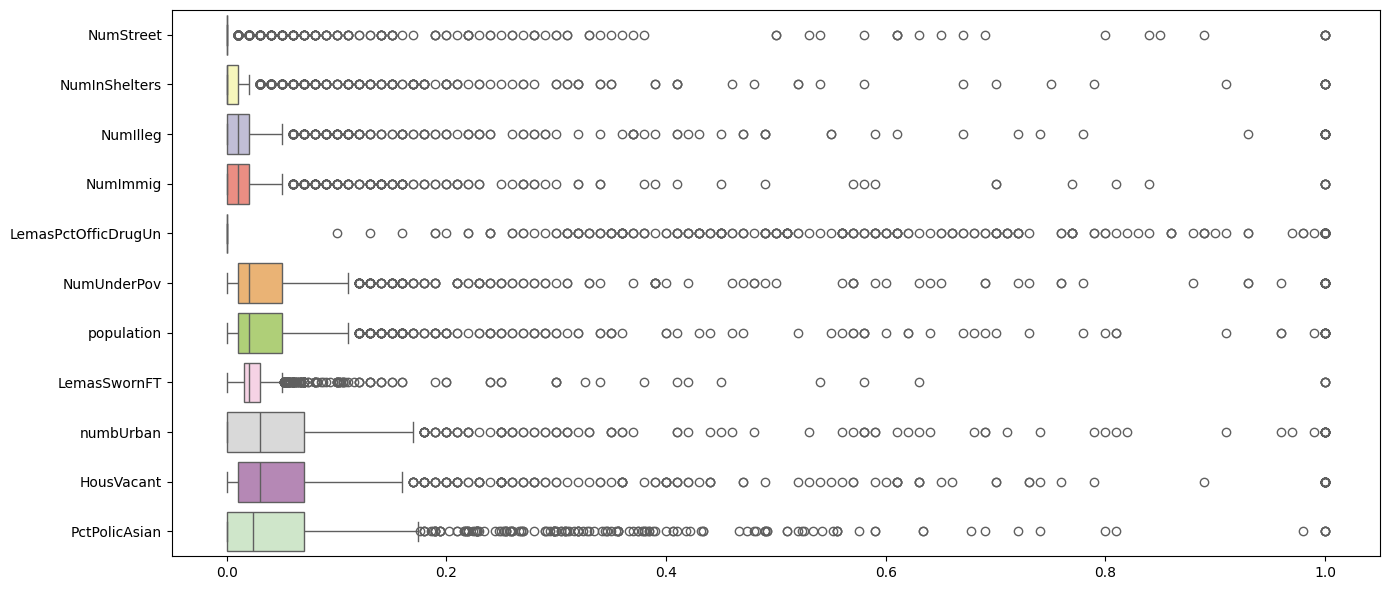

In [29]:
n = int(np.floor(np.sqrt(128)))
cv_n_feat = cv_df_sort.head(n).index.tolist()
print(f"Highest {n} CV features: {cv_n_feat} \n")
plt.rcdefaults()
X_cv_feat = X_train[cv_n_feat]
X_cv_feat_with_y = X_cv_feat.copy()
X_cv_feat_with_y["ViolentCrimesPerPop"] = y_train


plt_x_vs_y =sns.pairplot(X_cv_feat_with_y, x_vars=cv_n_feat, y_vars=["ViolentCrimesPerPop"], plot_kws={'color':'coral', 'alpha':0.7})
plt.suptitle('Features vs. Target', y=1.1, fontsize=15)
plt.show()

plt_x_vs_x = sns.pairplot(X_cv_feat,  plot_kws={'color':'coral', 'alpha':0.7})
plt_x_vs_x.map_upper(sns.kdeplot, levels=5, color='.2')
plt.suptitle('Feature Interactions', y=1.02, fontsize=15)
plt.show()

plt.figure(figsize=(14, 6))
sns.boxplot(data=X_cv_feat, orient='h', palette='Set3')
plt.tight_layout()
plt.show()


**Observations:**
- Visually there is no clear strong relationship between the target and features, however some relationships can be observed in features `NumIlleg`, `NumUnderPov` and `HousVacant` which show a positive trend with target `ViolentCrimesPerPop`.
- Several strong relationships among the features can be observed (`population` and `numbUrban`  are nearly perfectly correlated). This is evidence of high multicollinearity which might  inflate OLS coefficient variance and make the model unstable due to redundancy in features.
- From box plots, all features are heavily right-skewed with medians near 0, higher upper quartiles and numerous outliers at the upper end,

### (f) Fit OLS

In [30]:
ols = LinearRegression()
ols.fit(X_train, y_train)

y_pred_ols = ols.predict(X_test)
y_pred_ols_train = ols.predict(X_train)

mse_ols_train = mean_squared_error(y_train, y_pred_ols_train)
mse_ols_test = mean_squared_error(y_test, y_pred_ols)


print(f"OLS Train MSE: {mse_ols_train:.5f}")
print(f"OLS Test MSE: {mse_ols_test:.5f}")

OLS Train MSE: 0.01614
OLS Test MSE: 0.01754


### (g) Fit a ridge regression model

In [31]:
lambdas = np.logspace(-4,4,200)
ridge = RidgeCV(alphas=lambdas, cv=5)
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)
y_pred_ridge_train = ridge.predict(X_train)

mse_ridge_train = mean_squared_error(y_train, y_pred_ridge_train)
mse_ridge_test  = mean_squared_error(y_test,  y_pred_ridge)

print(f"Optimal lambda: {ridge.alpha_:.5f}")
print(f"Ridge Train MSE: {mse_ridge_train:.5f}")
print(f"Ridge Test  MSE: {mse_ridge_test:.5f}")


Optimal lambda: 2.64308
Ridge Train MSE: 0.01692
Ridge Test  MSE: 0.01732


### (h) Fit a LASSO model

In [32]:
lasso = LassoCV(alphas=lambdas, cv=5, max_iter=100000)
lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)
y_pred_lasso_train = lasso.predict(X_train)

mse_lasso_train = mean_squared_error(y_train, y_pred_lasso_train)
mse_lasso_test  = mean_squared_error(y_test,  y_pred_lasso)

print(f"Optimal lambda: {lasso.alpha_:.5f}")
print(f"LASSO Train MSE: {mse_lasso_train:.5f}")
print(f"LASSO Test  MSE: {mse_lasso_test:.5f}")

coef_lasso = pd.DataFrame({'Feature' : X_train.columns, 'Coefficient': lasso.coef_})
select_coef_lasso = coef_lasso[coef_lasso['Coefficient'] != 0]

print(f"Number of non-zero coef. from Lasso: {len(select_coef_lasso)}")
display(select_coef_lasso)


Optimal lambda: 0.00012
LASSO Train MSE: 0.01688
LASSO Test  MSE: 0.01753
Number of non-zero coef. from Lasso: 72


,Feature,Coefficient
2,racepctblack,0.228663
4,racePctAsian,-0.036224
5,racePctHisp,0.006577
6,agePct12t21,0.050565
7,agePct12t29,-0.243936
...,...,...
113,LandArea,0.018350
115,PctUsePubTrans,-0.044836
118,LemasPctPolicOnPatr,-0.008672
119,LemasGangUnitDeploy,-0.004519


#### Repeat with standardized features.

In [33]:
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_train_scaled[:] = scaler.fit_transform(X_train)
X_test_scaled = X_test.copy()
X_test_scaled[:] = scaler.transform(X_test)

lasso_stand = LassoCV(alphas=lambdas, cv=5, max_iter=100000)
lasso_stand.fit(X_train_scaled, y_train)

y_pred_lasso_stand = lasso_stand.predict(X_test_scaled)
y_pred_lasso_train_stand = lasso_stand.predict(X_train_scaled)

mse_lasso_train_stand = mean_squared_error(y_train, y_pred_lasso_train_stand)
mse_lasso_test_stand  = mean_squared_error(y_test,  y_pred_lasso_stand)

print("For Standardized Features:\n")
print(f"Optimal lambda: {lasso_stand.alpha_:.5f}")
print(f"LASSO Train MSE: {mse_lasso_train_stand:.5f}")
print(f"LASSO Test  MSE: {mse_lasso_test_stand:.5f}")

coef_lasso_stand = pd.DataFrame({'Feature' : X_train.columns, 'Coefficient': lasso_stand.coef_})
select_coef_lasso_stand = coef_lasso_stand[coef_lasso_stand['Coefficient'] != 0]

print(f"Number of non-zero coef. from Lasso: {len(select_coef_lasso_stand)}")
display(select_coef_lasso_stand)

For Standardized Features:

Optimal lambda: 0.00070
LASSO Train MSE: 0.01689
LASSO Test  MSE: 0.01756
Number of non-zero coef. from Lasso: 74


,Feature,Coefficient
0,population,-0.004022
2,racepctblack,0.057476
4,racePctAsian,-0.006054
6,agePct12t21,0.009514
7,agePct12t29,-0.038881
...,...,...
115,PctUsePubTrans,-0.009664
116,PolicCars,0.002430
118,LemasPctPolicOnPatr,-0.002944
119,LemasGangUnitDeploy,-0.001139


**LASSO Results:**
- **Original features:**  $\lambda = 0.00012$, Test MSE = 0.01753, 72 features selected
- **Standardized features:**  $\lambda = 0.00070$, Test MSE = 0.01756, 74 features selected
- Models form original and standardized features almost nearly identically (LASSO with raw features slightly better), since features in orginal data are already normalized and standardization has minimal effect on LASSO performance in this case.

### (i) Fit a PCR model

In [34]:
pca = PCA()
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_mse = {}

for m in range(1, len(X_train.columns) + 1):
    X_train_pca_m = X_train_pca[:, :m]
    lin_reg = LinearRegression()
    score = -cross_val_score(lin_reg, X_train_pca_m, y_train, cv=cv, scoring='neg_mean_squared_error')
    cv_mse[m] = score.mean()

M = min(cv_mse, key=cv_mse.get)

pcr = LinearRegression()
pcr.fit(X_train_pca[:, :M], y_train)

y_pred_pcr_train = pcr.predict(X_train_pca[:, :M])
y_pred_pcr_test = pcr.predict(X_test_pca[:, :M])

mse_pcr_train = mean_squared_error(y_train, y_pred_pcr_train)
mse_pcr_test = mean_squared_error(y_test, y_pred_pcr_test)

print(f"Optimal M: {M}")
print(f"PCR Train MSE: {mse_pcr_train:.5f}")
print(f"PCR Test  MSE: {mse_pcr_test:.5f}")


Optimal M: 43
PCR Train MSE: 0.01819
PCR Test  MSE: 0.01812


### (j) Fit a boosting tree

In [54]:
lambdas = np.logspace(-4, 4, 100)
cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_mse = {}

for l in lambdas:
    boost = xgb.XGBRegressor(reg_alpha=l, n_estimators=250, random_state=42)
    score = -cross_val_score(boost, X_train, y_train, cv=cv, scoring='neg_mean_squared_error')
    cv_mse[l] = score.mean()

lambda_star  = min(cv_mse, key=cv_mse.get)
boost_final = xgb.XGBRegressor(reg_alpha=lambda_star, n_estimators=250, random_state=42, n_jobs=-1)
boost_final.fit(X_train, y_train)

y_pred_boost_train = boost_final.predict(X_train)
y_pred_boost = boost_final.predict(X_test)
mse_boost_train = mean_squared_error(y_train, y_pred_boost_train)
mse_boost_test  = mean_squared_error(y_test,  y_pred_boost)

print(f"Optimal Lambda (L1): {lambda_star:.6f}")
print(f"Boosting Train MSE:  {mse_boost_train:.5f}")
print(f"Boosting Test  MSE:  {mse_boost_test:.5f}")

Optimal Lambda (L1): 2.782559
Boosting Train MSE:  0.00670
Boosting Test  MSE:  0.01767


In [53]:
summary = pd.DataFrame({
    'Model': ['OLS', 'Ridge', 'LASSO', 'LASSO(Std)', 'PCR', 'Boost'],
    'MSE Train': [mse_ols_train, mse_ridge_train, mse_lasso_train, mse_lasso_train_stand, mse_pcr_train, mse_boost_train],
    'MSE Test':  [mse_ols_test, mse_ridge_test, mse_lasso_test, mse_lasso_test_stand, mse_pcr_test, mse_boost_test]
})
summary = summary.sort_values('MSE Test').round(5)
display(summary)

,Model,MSE Train,MSE Test
1,Ridge,0.01692,0.01732
2,LASSO,0.01688,0.01753
0,OLS,0.01614,0.01754
3,LASSO(Std),0.01689,0.01756
5,Boost,0.00670,0.01767
4,PCR,0.01819,0.01812


### References:

- https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html
- https://scikit-learn.org/stable/modules/generated/sklearn.tree.plot_tree.html
- https://scikit-learn.org/stable/auto_examples/tree/plot_cost_complexity_pruning.html
- https://scikit-learn.org/stable/modules/generated/sklearn.impute.KNNImputer.html
- https://seaborn.pydata.org/generated/seaborn.pairplot.html
- https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.RidgeCV.html
- https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LassoCV.html
- https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html
- https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html
- https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html
- https://xgboost.readthedocs.io/en/latest/python/python_api.html